INFO:fiftyone.zoo.datasets:Downloading split 'validation' to '/root/fiftyone/coco-2017/validation' if necessary


Found annotations at '/root/fiftyone/coco-2017/raw/instances_val2017.json'


INFO:fiftyone.utils.coco:Found annotations at '/root/fiftyone/coco-2017/raw/instances_val2017.json'


Sufficient images already downloaded


INFO:fiftyone.utils.coco:Sufficient images already downloaded


Existing download of split 'validation' is sufficient


INFO:fiftyone.zoo.datasets:Existing download of split 'validation' is sufficient


Loading existing dataset 'coco-2017-validation-1'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


INFO:fiftyone.zoo.datasets:Loading existing dataset 'coco-2017-validation-1'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


✅ Loaded one COCO image containing a dog
🐶 Dog mask extracted successfully


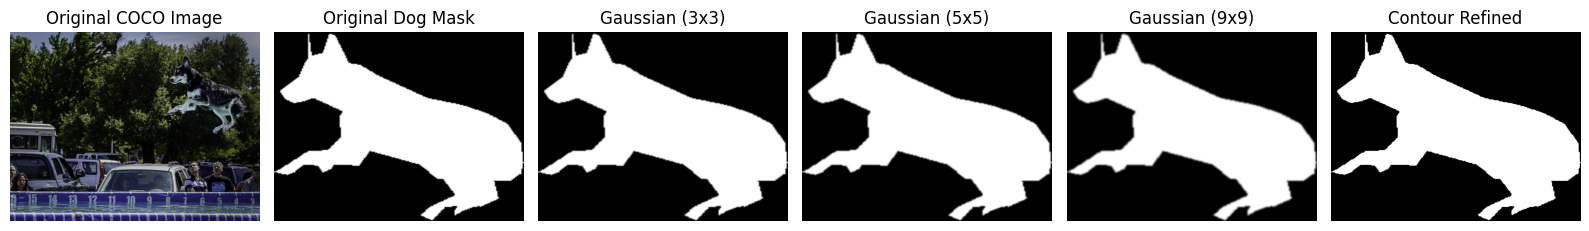

In [9]:
# ===========================================================
# STEP 1: Install Dependencies
# ===========================================================
!pip install fiftyone opencv-python-headless matplotlib -q

import fiftyone.zoo as foz
import fiftyone as fo
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ===========================================================
# STEP 2: Load Small COCO Dataset (Only Dog)
# ===========================================================
dataset = foz.load_zoo_dataset(
    "coco-2017",
    split="validation",
    label_types=["segmentations"],
    classes=["dog"],
    max_samples=1,
    only_matching=True
)
print("✅ Loaded one COCO image containing a dog")

# ===========================================================
# STEP 3: Get Image + Dog Mask
# ===========================================================
sample = dataset.first()
image_path = sample.filepath
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w, _ = image.shape

# Extract mask for the dog
dog_mask = None
if hasattr(sample, "ground_truth") and sample.ground_truth is not None:
    for det in sample.ground_truth.detections:
        if det.label == "dog" and det.mask is not None:
            dog_mask = (det.mask * 255).astype(np.uint8)
            dog_mask = cv2.resize(dog_mask, (w, h))
            break

if dog_mask is None:
    raise ValueError("No dog mask found in this image!")

print("🐶 Dog mask extracted successfully")

# ===========================================================
# STEP 4: Apply Gaussian Blur and Contour Refinement
# ===========================================================
blur3 = cv2.GaussianBlur(dog_mask, (3, 3), 0)
blur5 = cv2.GaussianBlur(dog_mask, (5, 5), 0)
blur9 = cv2.GaussianBlur(dog_mask, (9, 9), 0)

# Contour refinement
_, binary = cv2.threshold(blur5, 128, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
refined = np.zeros_like(dog_mask)
cv2.drawContours(refined, contours, -1, 255, thickness=cv2.FILLED)

# ===========================================================
# STEP 5: Visualization
# ===========================================================
titles = [
    "Original COCO Image",
    "Original Dog Mask",
    "Gaussian (3x3)",
    "Gaussian (5x5)",
    "Gaussian (9x9)",
    "Contour Refined"
]
images = [image_rgb, dog_mask, blur3, blur5, blur9, refined]

plt.figure(figsize=(16, 4))
for i in range(6):
    plt.subplot(1, 6, i + 1)
    if i == 0:
        plt.imshow(images[i])
    else:
        plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()
